In [1]:
import pandas as pd
import numpy as np
import pyranges as pr
from scipy.stats import spearmanr
import os
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

In [2]:
phyloP = pd.read_csv('../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_withPhyloP.tsv', sep='\t')
phyloP = phyloP.drop('mean_pcv2_large', axis = 1)
phyloP.shape

(39976, 5)

## PCv2

In [3]:
def load_and_process_pcv2(size, shift_values=[0, 5, 10, 15, 20]):
   """Load pcv2 files and calculate mean scores"""
   dfs = []
   for shift in shift_values:
       filename = f'../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_pcv2-{size}-2nd_shift_{shift}.tsv'
       df = pd.read_csv(filename, sep='\t')
       df['mean'] = df.iloc[:, 11:21].mean(axis=1)
       dfs.append(df['mean'])
   
   return sum(dfs) / len(dfs)

# Process all sizes
for size in ['large', 'medium', 'small']:
    print(f'Processing {size} model......')
    phyloP[f'pcv2_{size}'] = load_and_process_pcv2(size, shift_values=[0, 5, 10, 15, 20])

Processing large model......
Processing medium model......
Processing small model......


In [4]:
phyloP.head()

,chr,start,end,location,meanPhyloP,pcv2_large,pcv2_medium,pcv2_small
0,1,17983,18028,1:17983-18028,NaN,-0.103984,-0.091119,-0.014662
1,1,45457,45493,1:45457-45493,0.293157,-0.036220,0.004624,-0.012520
2,1,59366,59393,1:59366-59393,0.693324,-0.058891,-0.065702,-0.047644
3,1,60028,60057,1:60028-60057,0.319348,-0.015226,-0.004374,-0.004866
4,1,67533,67578,1:67533-67578,-0.099907,-0.045909,-0.021957,-0.040104


## Evo2

In [5]:
shifts = [0, 5, 10, 15, 20]
evo2_dfs = []

for shift in shifts:
    df = pd.read_csv(f'../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_Evo2_shift_{shift}.tsv', sep='\t')
    df['mean_evo2'] = df.iloc[:, 11:21].mean(axis=1)
    evo2_dfs.append(df['mean_evo2'])

phyloP['evo2'] = pd.concat(evo2_dfs, axis=1).mean(axis=1)

## GPN

In [6]:
shifts = [0, 5, 10, 15, 20]
gpn_dfs = []

for shift in shifts:
    df = pd.read_csv(f'../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_GPN_shift_{shift}.tsv', sep='\t')
    df['mean_gpn'] = df.iloc[:, 11:21].mean(axis=1)
    gpn_dfs.append(df['mean_gpn'])

phyloP['gpn'] = pd.concat(gpn_dfs, axis=1).mean(axis=1)

## PlantCAD

In [7]:
shifts = [0, 5, 10, 15, 20]
pcv1_dfs = []

for shift in shifts:
    df = pd.read_csv(f'../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_pcv1_shift_{shift}.tsv', sep='\t')
    df['mean_pcv1'] = df.iloc[:, 11:21].mean(axis=1)
    pcv1_dfs.append(df['mean_pcv1'])

phyloP['pcv1'] = pd.concat(pcv1_dfs, axis=1).mean(axis=1)

In [8]:
phyloP.head()

,chr,start,end,location,meanPhyloP,pcv2_large,pcv2_medium,pcv2_small,evo2,gpn,pcv1
0,1,17983,18028,1:17983-18028,NaN,-0.103984,-0.091119,-0.014662,-0.148607,-0.028061,-0.018219
1,1,45457,45493,1:45457-45493,0.293157,-0.036220,0.004624,-0.012520,-0.067541,-0.026121,-0.025303
2,1,59366,59393,1:59366-59393,0.693324,-0.058891,-0.065702,-0.047644,-0.026825,-0.041332,-0.060063
3,1,60028,60057,1:60028-60057,0.319348,-0.015226,-0.004374,-0.004866,-0.001196,0.004609,-0.007004
4,1,67533,67578,1:67533-67578,-0.099907,-0.045909,-0.021957,-0.040104,-0.314441,-0.025666,-0.025656


In [9]:
phyloP.to_csv('../../../results/SV_effect/outputs/Ath_Simulated_DEL_Len_1-50_scores.tsv', sep='\t', index=False)

In [10]:
models = ['pcv2_large', 'pcv2_medium', 'pcv2_small', 'evo2', 'gpn', 'pcv1']

results = {}
relevant_mask = (phyloP['meanPhyloP'] > 1) | (phyloP['meanPhyloP'] < 0)
filtered_true_labels = np.where(phyloP['meanPhyloP'][relevant_mask] > 1, 1, 0)

for model in models:
   filtered_scores = phyloP[model][relevant_mask] * -1
   auc_value = roc_auc_score(filtered_true_labels, filtered_scores)
   ap_value = average_precision_score(filtered_true_labels, filtered_scores)
   results[model] = {'AUC': auc_value, 'AP': ap_value}

results_df = pd.DataFrame(results).T
results_df

,AUC,AP
pcv2_large,0.845155,0.841029
pcv2_medium,0.833551,0.833437
pcv2_small,0.794833,0.794626
evo2,0.839524,0.770591
gpn,0.758772,0.727668
pcv1,0.842769,0.823319


In [11]:
filtered_true_labels.sum()/len(filtered_true_labels)

0.4239004149377593

In [12]:
custom_order = ['pcv1', 'pcv2_small', 'pcv2_medium', 'pcv2_large', 'evo2', 'gpn']
results_df = results_df.reindex(custom_order)

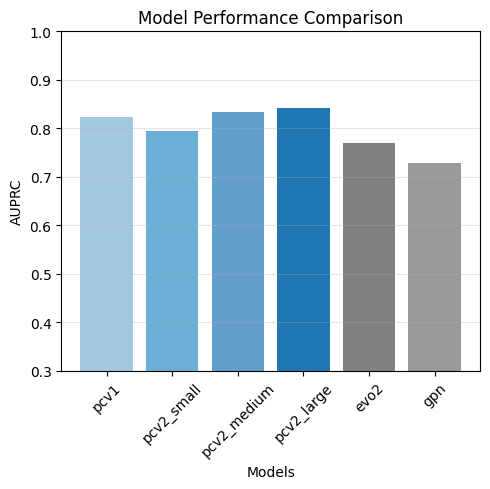

In [13]:
plt.figure(figsize=(5, 5))
colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff',  '#808080','#999999', '#d3d3d3']

bars = plt.bar(results_df.index, results_df['AP'], color=colors)

plt.xlabel('Models')
plt.ylabel('AUPRC')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim(0.3, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('AUPRC.pdf', format='pdf', bbox_inches='tight')
plt.show()